In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import squarify
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

import ipywidgets as widgets
from matplotlib import patches as mpatches
from IPython.display import display, clear_output
from plotly.subplots import make_subplots

from imblearn.over_sampling import SMOTE
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

pd.options.mode.chained_assignment = None

# 1. Tiền xử lý dữ liệu (Data preprocessing)

Data Description
App Name: Tên của ứng dụng trên Google Play Store.

App Id: ID duy nhất của ứng dụng trên Google Play Store.

Category: Thể loại của ứng dụng (ví dụ: Tools, Education, Entertainment, etc.).

Rating: Đánh giá trung bình của ứng dụng, thường từ 0 đến 5.

Rating Count: Số lượng đánh giá của ứng dụng.

Installs: Số lần cài đặt ước tính của ứng dụng.

Minimum Installs: Số lần cài đặt tối thiểu ước tính của ứng dụng.

Maximum Installs: Số lần cài đặt tối đa ước tính của ứng dụng.

Free: Cho biết ứng dụng là miễn phí (True) hay trả phí (False).

Price: Giá của ứng dụng (chỉ áp dụng cho các ứng dụng trả phí).

Currency: Đơn vị tiền tệ của giá ứng dụng.

Size: Kích thước tải về của ứng dụng.

Minimum Android: Phiên bản Android tối thiểu mà ứng dụng yêu cầu để có thể chạy. Điều này giúp người dùng biết liệu thiết bị của họ có tương thích với ứng dụng hay không.

Developer Id: ID của nhà phát triển ứng dụng.

Developer Website: Địa chỉ website chính thức của nhà phát triển ứng dụng. Đây là nơi người dùng có thể tìm thêm thông tin về nhà phát triển hoặc các ứng dụng khác của họ.

Developer Email: Email liên lạc của nhà phát triển ứng dụng.

Content Rating: Đánh giá nội dung của ứng dụng, chỉ ra độ tuổi phù hợp để sử dụng ứng dụng.

Ad Supported: Cho biết ứng dụng có hỗ trợ quảng cáo (True) hay không (False).

In App Purchases: Cho biết ứng dụng có tính năng mua hàng trong ứng dụng (True) hay không (False).

Editors Choice: Cho biết ứng dụng có được chọn làm Editors' Choice trên Google Play hay không.

Released: Ngày phát hành ứng dụng.

Last Updated: Ngày cập nhật ứng dụng gần nhất.

Privacy Policy: URL của chính sách bảo mật của ứng dụng.

Scraped Time: Thời gian dữ liệu ứng dụng được thu thập hoặc "scraped" từ Google Play Store. Điều này thường được ghi lại dưới dạng timestamp và cho biết dữ liệu được cập nhật lần cuối vào thời điểm nào.


In [2]:
file_path = r"C:\Users\minhh\Desktop\Google-Playstore.csv"
data = pd.read_csv(file_path)
data.head()

,App Name,App Id,Category,Rating,Rating Count,Installs,Minimum Installs,Maximum Installs,Free,Price,...,Developer Website,Developer Email,Released,Last Updated,Content Rating,Privacy Policy,Ad Supported,In App Purchases,Editors Choice,Scraped Time
0,Gakondo,com.ishakwe.gakondo,Adventure,0.0,0.0,10+,10.0,15,True,0.0,...,https://beniyizibyose.tk/#/,jean21101999@gmail.com,"Feb 26, 2020","Feb 26, 2020",Everyone,https://beniyizibyose.tk/projects/,False,False,False,2021-06-15 20:19:35
1,Ampere Battery Info,com.webserveis.batteryinfo,Tools,4.4,64.0,"5,000+",5000.0,7662,True,0.0,...,https://webserveis.netlify.app/,webserveis@gmail.com,"May 21, 2020","May 06, 2021",Everyone,https://dev4phones.wordpress.com/licencia-de-uso/,True,False,False,2021-06-15 20:19:35
2,Vibook,com.doantiepvien.crm,Productivity,0.0,0.0,50+,50.0,58,True,0.0,...,NaN,vnacrewit@gmail.com,"Aug 9, 2019","Aug 19, 2019",Everyone,https://www.vietnamairlines.com/vn/en/terms-an...,False,False,False,2021-06-15 20:19:35
3,Smart City Trichy Public Service Vehicles 17UC...,cst.stJoseph.ug17ucs548,Communication,5.0,5.0,10+,10.0,19,True,0.0,...,http://www.climatesmarttech.com/,climatesmarttech2@gmail.com,"Sep 10, 2018","Oct 13, 2018",Everyone,NaN,True,False,False,2021-06-15 20:19:35
4,GROW.me,com.horodyski.grower,Tools,0.0,0.0,100+,100.0,478,True,0.0,...,http://www.horodyski.com.pl,rmilekhorodyski@gmail.com,"Feb 21, 2020","Nov 12, 2018",Everyone,http://www.horodyski.com.pl,False,False,False,2021-06-15 20:19:35


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2312944 entries, 0 to 2312943
Data columns (total 24 columns):
 #   Column             Dtype  
---  ------             -----  
 0   App Name           object 
 1   App Id             object 
 2   Category           object 
 3   Rating             float64
 4   Rating Count       float64
 5   Installs           object 
 6   Minimum Installs   float64
 7   Maximum Installs   int64  
 8   Free               bool   
 9   Price              float64
 10  Currency           object 
 11  Size               object 
 12  Minimum Android    object 
 13  Developer Id       object 
 14  Developer Website  object 
 15  Developer Email    object 
 16  Released           object 
 17  Last Updated       object 
 18  Content Rating     object 
 19  Privacy Policy     object 
 20  Ad Supported       bool   
 21  In App Purchases   bool   
 22  Editors Choice     bool   
 23  Scraped Time       object 
dtypes: bool(4), float64(4), int64(1), object(15)
memor

In [4]:
data.drop_duplicates(keep=False,inplace=True)
len(data)

2312944

## Loại bỏ những cột không cần thiết và những hàng bị khuyết data

In [5]:
data_cleaned = data.drop(['Developer Website', 'Developer Email', 'Developer Id', 'Privacy Policy', 'Scraped Time'], axis=1)
data_cleaned = data.dropna()

In [6]:
print("Số lượng dòng data trước khi xử lý: ", len(data))
print("Số lượng dòng của data sau khi xử lý: ", len(data_cleaned))
print("Tổng số dòng của data đã xử lý: ", len(data) - len(data_cleaned))

Số lượng dòng data trước khi xử lý:  2312944
Số lượng dòng của data sau khi xử lý:  1287191
Tổng số dòng của data đã xử lý:  1025753


In [7]:
data_cleaned['Installs'] = data_cleaned['Installs'].str.replace(',', '').str.replace('+', '').astype('int64')


In [8]:
data_cleaned.head()

,App Name,App Id,Category,Rating,Rating Count,Installs,Minimum Installs,Maximum Installs,Free,Price,...,Developer Website,Developer Email,Released,Last Updated,Content Rating,Privacy Policy,Ad Supported,In App Purchases,Editors Choice,Scraped Time
0,Gakondo,com.ishakwe.gakondo,Adventure,0.0,0.0,10,10.0,15,True,0.0,...,https://beniyizibyose.tk/#/,jean21101999@gmail.com,"Feb 26, 2020","Feb 26, 2020",Everyone,https://beniyizibyose.tk/projects/,False,False,False,2021-06-15 20:19:35
1,Ampere Battery Info,com.webserveis.batteryinfo,Tools,4.4,64.0,5000,5000.0,7662,True,0.0,...,https://webserveis.netlify.app/,webserveis@gmail.com,"May 21, 2020","May 06, 2021",Everyone,https://dev4phones.wordpress.com/licencia-de-uso/,True,False,False,2021-06-15 20:19:35
4,GROW.me,com.horodyski.grower,Tools,0.0,0.0,100,100.0,478,True,0.0,...,http://www.horodyski.com.pl,rmilekhorodyski@gmail.com,"Feb 21, 2020","Nov 12, 2018",Everyone,http://www.horodyski.com.pl,False,False,False,2021-06-15 20:19:35
5,IMOCCI,com.imocci,Social,0.0,0.0,50,50.0,89,True,0.0,...,http://www.imocci.com,info@imocci.com,"Dec 24, 2018","Dec 20, 2019",Teen,https://www.imocci.com/wp-content/uploads/2018...,False,True,False,2021-06-15 20:19:35
9,Neon 3d Iron Tech Keyboard Theme,com.ikeyboard.theme.neon_3d.iron.tech,Personalization,4.7,820.0,50000,50000.0,62433,True,0.0,...,https://trendyteme888-31139.web.app,trendyteme.888@gmail.com,"Sep 22, 2019","Oct 07, 2020",Everyone,http://bit.ly/EmojiThemePro,True,False,False,2021-06-15 20:19:35


# 2. Mô tả dữ liệu (Data Description)

In [9]:
data_cleaned.describe().T

,count,mean,std,min,25%,50%,75%,max
Rating,1287191.0,2.315500,2.090373e+00,0.0,0.0,3.3,4.3,5.000000e+00
Rating Count,1287191.0,4470.701667,2.594790e+05,0.0,0.0,7.0,61.0,1.385576e+08
Installs,1287191.0,269130.516292,1.834388e+07,0.0,100.0,500.0,10000.0,1.000000e+10
Minimum Installs,1287191.0,269130.516292,1.834388e+07,0.0,100.0,500.0,10000.0,1.000000e+10
Maximum Installs,1287191.0,467607.647233,2.780474e+07,0.0,115.0,949.0,10743.0,1.205763e+10
Price,1287191.0,0.109972,2.438043e+00,0.0,0.0,0.0,0.0,4.000000e+02


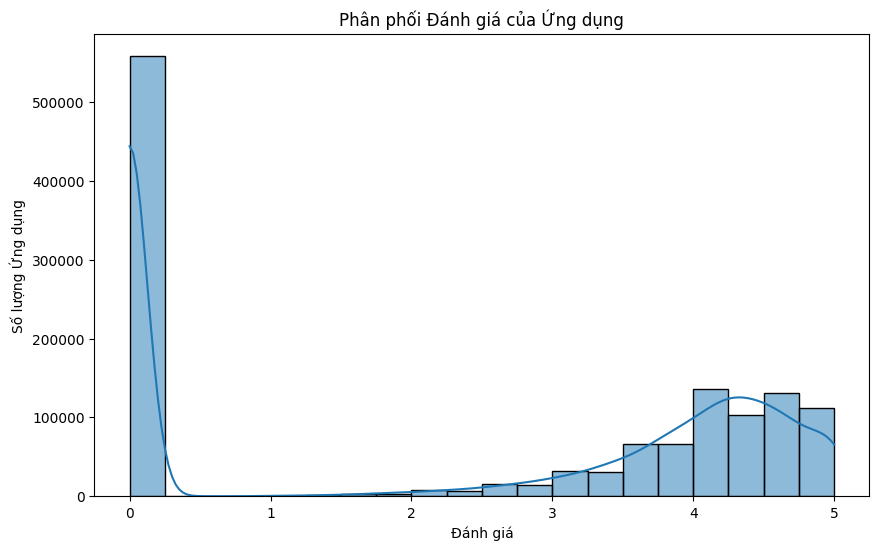

In [10]:
plt.figure(figsize=(10, 6))
sns.histplot(data=data_cleaned, x="Rating", bins=20, kde=True)
plt.title("Phân phối Đánh giá của Ứng dụng")
plt.xlabel("Đánh giá")
plt.ylabel("Số lượng Ứng dụng")
plt.show()

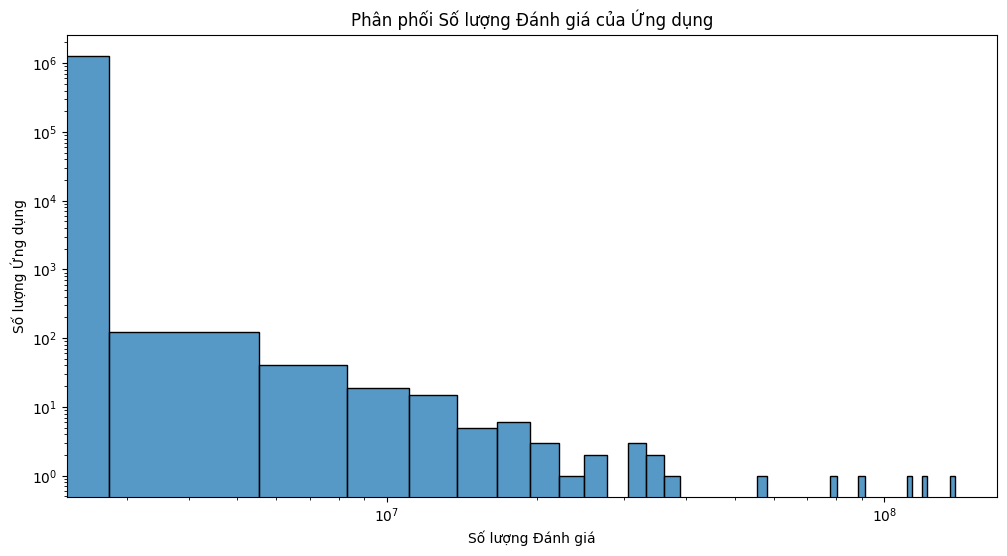

In [11]:
plt.figure(figsize=(12, 6))
sns.histplot(data=data_cleaned, x="Rating Count", bins=50, kde=False)
plt.title('Phân phối Số lượng Đánh giá của Ứng dụng')
plt.xlabel('Số lượng Đánh giá')
plt.ylabel('Số lượng Ứng dụng')
plt.xscale('log')
plt.yscale('log')
plt.show()

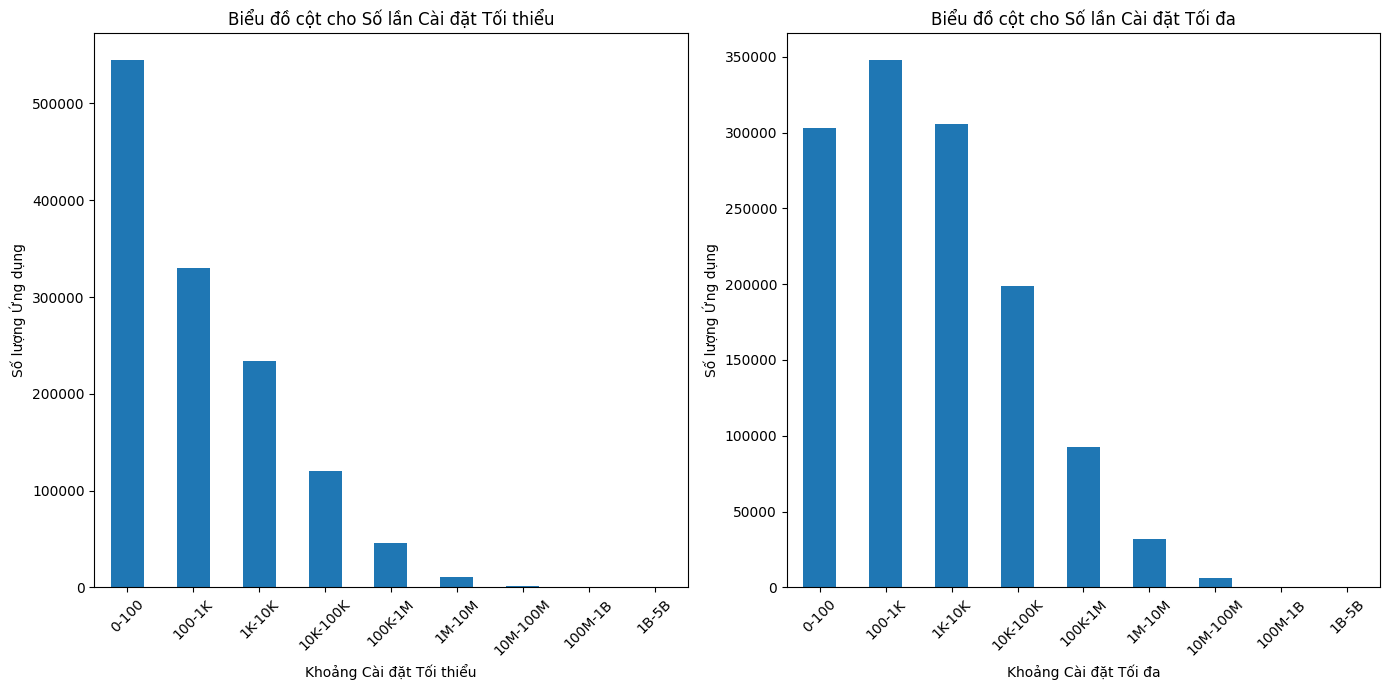

In [12]:
install_bins = [0, 100, 1000, 10000, 100000, 1000000, 10000000, 100000000, 1000000000, 5000000000]
install_labels = ['0-100', '100-1K', '1K-10K', '10K-100K', '100K-1M', '1M-10M', '10M-100M', '100M-1B', '1B-5B']

data_cleaned['Min_Install_Category'] = pd.cut(data_cleaned['Minimum Installs'], bins=install_bins, labels=install_labels, include_lowest=True)
data_cleaned['Max_Install_Category'] = pd.cut(data_cleaned['Maximum Installs'], bins=install_bins, labels=install_labels, include_lowest=True)

min_install_counts = data_cleaned['Min_Install_Category'].value_counts(sort=False)
max_install_counts = data_cleaned['Max_Install_Category'].value_counts(sort=False)

plt.figure(figsize=(14, 7))

plt.subplot(1, 2, 1)
min_install_counts.plot(kind='bar')
plt.title('Biểu đồ cột cho Số lần Cài đặt Tối thiểu')
plt.xlabel('Khoảng Cài đặt Tối thiểu')
plt.ylabel('Số lượng Ứng dụng')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
max_install_counts.plot(kind='bar')
plt.title('Biểu đồ cột cho Số lần Cài đặt Tối đa')
plt.xlabel('Khoảng Cài đặt Tối đa')
plt.ylabel('Số lượng Ứng dụng')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

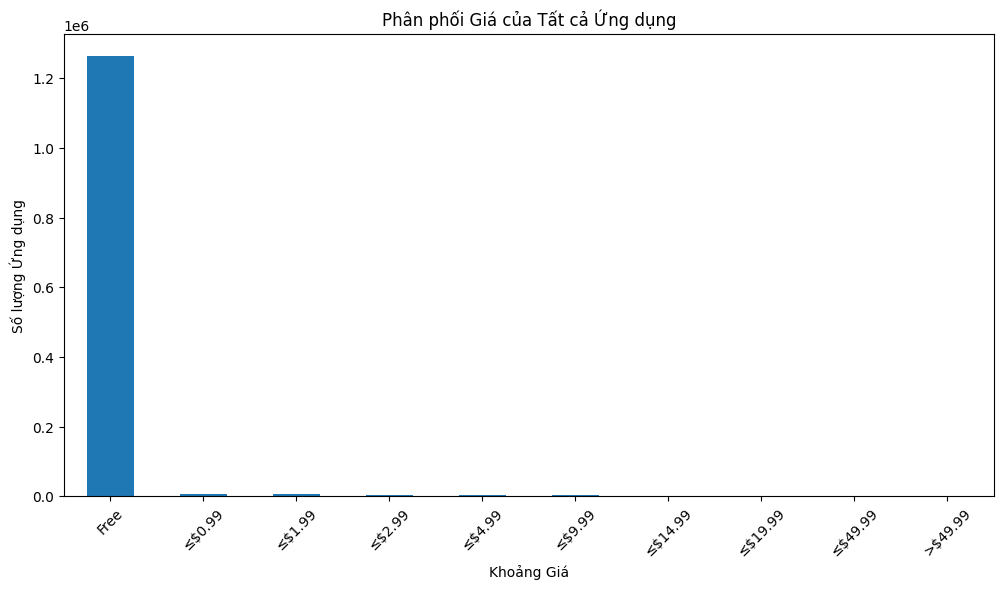

In [13]:
price_bins = [-0.01, 0.00, 0.99, 1.99, 2.99, 4.99, 9.99, 14.99, 19.99, 49.99, 209.99]
price_labels = ['Free', '≤$0.99', '≤$1.99', '≤$2.99', '≤$4.99', '≤$9.99', '≤$14.99', '≤$19.99', '≤$49.99', '>$49.99']

data_cleaned['Price Category'] = pd.cut(data_cleaned['Price'], bins=price_bins, labels=price_labels, include_lowest=True)

price_category_counts = data_cleaned['Price Category'].value_counts(sort=False)

plt.figure(figsize=(12, 6))
price_category_counts.plot(kind='bar')
plt.title('Phân phối Giá của Tất cả Ứng dụng')
plt.xlabel('Khoảng Giá')
plt.ylabel('Số lượng Ứng dụng')
plt.xticks(rotation=45)
plt.show()

# 3. Basic EDA

In [14]:
new_data = data_cleaned[(data_cleaned['Installs'] != 0) & (data_cleaned['Rating Count'] != 0)]
print(data_cleaned.shape)
print(new_data.shape)



(1287191, 27)
(729066, 27)


In [15]:
cols = ['Editors Choice', 'Category', 'Free', 'Rating', 'Installs', 'Content Rating', 'Price', 'Ad Supported']
new_data = new_data.filter(cols, axis=1)
new_data.head(100)

,Editors Choice,Category,Free,Rating,Installs,Content Rating,Price,Ad Supported
1,False,Tools,True,4.4,5000,Everyone,0.0,True
9,False,Personalization,True,4.7,50000,Everyone,0.0,True
12,False,Travel & Local,True,3.9,10000,Everyone,0.0,True
14,False,Travel & Local,True,3.7,10000,Everyone,0.0,False
15,False,Food & Drink,True,4.2,1000,Everyone,0.0,False
...,...,...,...,...,...,...,...,...
341,False,Racing,True,3.4,100000,Everyone,0.0,False
345,False,Education,True,4.3,500,Everyone,0.0,False
346,False,Lifestyle,True,4.2,10000,Everyone,0.0,False
349,False,Finance,True,4.7,100,Everyone,0.0,False


##### Câu hỏi về Editors'Choice - Đâu là yếu tố ảnh hưởng tới editors choice
1. Quan hệ giữa thể loại ứng dụng và editor choice (Category vs Editor's Choice)
2. Đánh giá của người dùng và editor's choice (Rating vs Editor's Choice)
3. Lượt tải từ người dùng và editor's choice (Install vs Editor's Choice)
4. Độ tuổi sử dụng ứng dụng và editor's chocie (Content Rating vs Editor's Choice)
5. Giá tiền của ứng dụng và editor's choice (Price vs Editor's Choice)
6. App có hỗ trợ quảng cáo có ảnh hưởng tới editor choice không  (Ad Supported vs Editor's Choice)


In [67]:
data_t_editorChoice = new_data[new_data['Editors Choice'] == True]
data_f_editorChoice = new_data[new_data['Editors Choice'] == False]

data_t_editorChoice

,Editors Choice,Category,Free,Rating,Installs,Content Rating,Price,Ad Supported
885,True,Health & Fitness,True,4.2,10000000,Everyone,0.0,False
1169,True,Strategy,True,4.0,1000000,Teen,0.0,True
6107,True,Adventure,True,4.0,10000000,Teen,0.0,False
8913,True,Word,True,4.4,10000000,Everyone,0.0,True
9113,True,Education,True,4.6,10000000,Everyone,0.0,False
...,...,...,...,...,...,...,...,...
2307387,True,Strategy,True,4.0,5000000,Everyone 10+,0.0,True
2307456,True,Productivity,True,4.5,10000000,Everyone,0.0,False
2309510,True,Maps & Navigation,True,4.3,100000,Everyone,0.0,False
2311822,True,Simulation,True,4.5,10000000,Everyone,0.0,True


1. Ad Supported vs editor's choice & non editor's choice
2. Free App and Paid App vs editor's choice & non edittor's choice
3. Content Rating vs Editor's Choice and Non-Editor's Choice App

In [68]:
dt_ad_ed_T = data_t_editorChoice['Ad Supported'].value_counts(normalize=True).reset_index().rename(columns={"item":"count", "index": "item"})
dt_ad_ed_F = data_f_editorChoice['Ad Supported'].value_counts(normalize=True).reset_index().rename(columns={"item":"count", "index": "item"})
dt_free_ed_F = data_f_editorChoice['Free'].value_counts(normalize=True).reset_index().rename(columns={"item":"count", "index": "item"})
dt_free_ed_T = data_t_editorChoice['Free'].value_counts(normalize=True).reset_index().rename(columns={"item":"count", "index": "item"})
dt_rContent_ed_T = data_t_editorChoice['Content Rating'].value_counts(normalize=True).reset_index().rename(columns={"item":"count", "index": "item"})
dt_rContent_ed_F = data_f_editorChoice['Content Rating'].value_counts(normalize=True).reset_index().rename(columns={"item":"count", "index": "item"})


dt_ad_ed_T

,Ad Supported,proportion
0,True,0.661499
1,False,0.338501


In [69]:
def hist_TF(da):
    fig = plt.figure(figsize=(13, 11))

    if da == 'Ad Supported':
        data1 = dt_ad_ed_T
        data2 = dt_ad_ed_F
        ten = "(App hỗ trợ ads và app không hỗ trợ ad)"
    elif da == 'Content Rating':
        data1 = dt_rContent_ed_T
        data2 = dt_rContent_ed_F
        ten = "(Dựa theo đọ tuổi phù hợp cho app)"
    else:
        data1 = dt_free_ed_T
        data2 = dt_free_ed_F
        ten = "(App free và App mất tiền)"

    sns.set_theme(context='talk', style='white', palette='tab10')
    sns.barplot(data=data1, x=da, y='proportion', color=sns.set_palette('Set1'), label='Editor Choice')
    sns.barplot(data=data2, x=da, y='proportion', color=sns.set_palette('Set2'), label='Non-Editor Choice', alpha=0.5)
    plt.title("Phân Bố Định Dạng Histogram dựa trên Editor Choice" + ten)
    plt.tight_layout()
    plt.show()

In [70]:
label1 = widgets.Label(value='Phân bố dạng histogram')
display(label1)
wRB = widgets.RadioButtons(options=['Ad Supported','Free', 'Content Rating'])

def button_click(bc):
    clear_output()
    display(widgets.HBox([wRB, bc]))
    hist_TF(wRB.value)

bc = widgets.Button(description='Draw', icon='check', button_style='danger')
bc.on_click(button_click)
display(widgets.HBox([wRB, bc]))

Label(value='Phân bố dạng histogram')

3. Category vs Editor's Choice

In [71]:
## Category
cat_editor_counts = pd.DataFrame(data  = data_t_editorChoice.groupby(['Category'])['Editors Choice'].count().sort_values(ascending=False))
cat_editor_counts.columns = ['cat counts']
cat_editor_counts = cat_editor_counts.reset_index()
cat_editor_counts

,Category,cat counts
0,Action,70
1,Puzzle,64
2,Role Playing,59
3,Simulation,56
4,Health & Fitness,41
5,Casual,39
6,Education,39
7,Strategy,34
8,Adventure,33
9,Sports,32


In [72]:
cat_fig = px.pie(cat_editor_counts, values='cat counts', names='Category')
cat_fig.update_traces(textposition='inside')
cat_fig.update_layout(uniformtext_minsize=12, uniformtext_mode='hide')
cat_fig.update_layout(title_text="Tỷ lệ Editor's Choice của các App Dựa Trên Category")
cat_fig.show()

In [73]:
dt_cat_ed_T = data_t_editorChoice['Category'].value_counts(normalize=True).reset_index().rename(columns={"item":"count", "index": "item"})
dt_cat_ed_F = data_f_editorChoice['Category'].value_counts(normalize=True).reset_index().rename(columns={"item":"count", "index": "item"})
dt_cat_ed_F

,Category,proportion
0,Education,0.098730
1,Music & Audio,0.067768
2,Tools,0.058099
3,Entertainment,0.057153
4,Business,0.051942
5,Lifestyle,0.049357
6,Books & Reference,0.047142
7,Finance,0.039263
8,Personalization,0.036711
9,Travel & Local,0.032280


In [74]:
def top_category(n=10, cat_editor_counts=None):
    cat = cat_editor_counts.head(n)
    N = str(n)
    parent = ["Top The Loai cho Editor's Choice"] * len(cat)

    # Creating Treemap
    fig1 = go.Figure(go.Treemap(
        labels=cat['Category'],
        parents=parent,
        values=cat['cat counts']
    ))
    fig1.update_traces(root_color="tomato", textinfo="label+percent entry")
    fig1.update_layout(
        margin=dict(t=50, l=25, r=25, b=25),
        title=("Top " + N +  " Categories for Editor's Choice (Treemap)"),
        uniformtext=dict(minsize=12, mode='hide')
    )
    fig1.show()

    # Creating Bar Plot
    fig = make_subplots(rows=1, cols=1)

    fig.add_trace(go.Bar(x=cat['Category'], y=cat['cat counts'], width=0.5, showlegend=False))
    fig.update_layout(
        title_text="Top " + N + " Categories for Editor's Choice (Bar Plot)",
        xaxis=dict(title='Category'),
        yaxis=dict(title='Count'),
        margin=dict(t=50, l=25, r=25, b=25),
        uniformtext=dict(minsize=12, mode='hide')
    )
    fig.show()

In [75]:

wLabel2 = widgets.Label(value='Top Categories With Editor Choice')
wInt = widgets.IntSlider(value=10, min=0, max=47, step=1, description='Number of Categories')
display(wLabel2)
wKQ = widgets.interact(top_category, n=wInt, cat_editor_counts=widgets.fixed(cat_editor_counts))

Label(value='Top Categories With Editor Choice')

interactive(children=(IntSlider(value=10, description='Number of Categories', max=47), Output()), _dom_classes…

4. Rating vs Editor Choice and Non-Editor Choice
5. Install vs Editor Choice and Non-Editor Choice
6. Price vs Editor Choice and Non-Editor Choice

In [76]:
dt_install_ed_T = data_t_editorChoice['Installs'].value_counts().reset_index().rename(columns={"item":"count", "index": "item"})
dt_install_ed_F = data_f_editorChoice['Installs'].value_counts().reset_index().rename(columns={"item":"count", "index": "item"})

dt_rating_ed_T = data_t_editorChoice['Rating'].value_counts().reset_index().rename(columns={"item":"count", "index": "item"})
dt_rating_ed_F = data_f_editorChoice['Rating'].value_counts().reset_index().rename(columns={"item":"count", "index": "item"})

dt_price_ed_T = data_t_editorChoice['Price'].value_counts().reset_index().rename(columns={"item":"count", "index": "item"})
dt_price_ed_F = data_f_editorChoice['Price'].value_counts().reset_index().rename(columns={"item":"count", "index": "item"})


In [77]:
def boxplot_TF(da):
    fig, axes = plt.subplots(1, 2, figsize=(20, 10))  # Creating subplots with 1 row and 2 columns

    if da == 'Installs':
        data1 = dt_install_ed_T
        data2 = dt_install_ed_F
        ten = ("Dựa Trên số lượt tải")
    elif da == 'Rating':
        data1 = dt_rating_ed_T
        data2 = dt_rating_ed_F
        ten = ("Dựa Trên đánh giá từ người dùng")
    elif da == 'Price':
        data1 = dt_price_ed_T
        data2 = dt_price_ed_F
        ten = ("Dựa Trên giá của app")

    sns.set_theme(context='talk', style='white', palette='tab10')

    # Scatter plot for Editor's Choice
    sns.scatterplot(data=data1, x=da, y='count', color=sns.color_palette('Set2')[0], label='Editor Choice', ax=axes[0])
    axes[0].set_title("Editor's Choice")

    # Scatter plot for Non-Editor's Choice
    sns.scatterplot(data=data2, x=da, y='count', color=sns.color_palette('Set2')[1], alpha=0.5, label='Non-Editor Choice', ax=axes[1])
    axes[1].set_title("Non-Editor's Choice")

    plt.title("Phân Bố Định Dạng Histogram dựa trên Editor Choice" + ten)
    plt.tight_layout()
    plt.show()

In [78]:

label2 = widgets.Label(value='Phân bố dạng histogram của data dựa trên Risk-Flag')
display(label2)
wRB2 = widgets.RadioButtons(options=['Installs','Price', 'Rating'])

def button_click2(bc2):
    clear_output()
    display(widgets.HBox([wRB2, bc2]))
    boxplot_TF(wRB2.value)

bc2 = widgets.Button(description='Draw', icon='check', button_style='danger')
bc2.on_click(button_click2)
display(widgets.HBox([wRB2, bc2]))

Label(value='Phân bố dạng histogram của data dựa trên Risk-Flag')

# 4. Phân tích dữ liệu đa biến

In [28]:
new_data = data_cleaned[(data_cleaned['Installs'] != 0) & (data_cleaned['Rating Count'] != 0)]

print(data_cleaned.shape)
print(new_data.shape)

(1287191, 27)
(729066, 27)


In [29]:
install_bins = [0, 100, 1000, 10000, 100000, 1000000, 10000000, 100000000, 1000000000, 5000000000]
install_labels = ['0-100', '100-1K', '1K-10K', '10K-100K', '100K-1M', '1M-10M', '10M-100M', '100M-1B', '1B-5B']

price_bins = [-0.01, 0.00, 0.99, 1.99, 2.99, 4.99, 9.99, 14.99, 19.99, 49.99, 209.99]
price_labels = ['Free', '≤$0.99', '≤$1.99', '≤$2.99', '≤$4.99', '≤$9.99', '≤$14.99', '≤$19.99', '≤$49.99', '>$49.99']

def Category_EC(Category):
       True_Color = mpatches.Patch(color='red')
       False_Color = mpatches.Patch(color='green')
       fig = plt.figure(figsize=(13,11))
       ax1 = fig.add_subplot(3,2,4)
       ax1_5 = fig.add_subplot(3,2,3)
       ax3 = fig.add_subplot(3,2,5)
       ax4 = fig.add_subplot(3,2,6)
       ax2 = fig.add_subplot(3,1,1)


       df = new_data
       df['Range_Installs'] = new_data.groupby(['Category'])['Installs'].transform(pd.cut,bins=install_bins, labels=install_labels, include_lowest=True)
       df['Range_Price'] = new_data.groupby(['Category'])['Price'].transform(pd.cut,bins=price_bins, labels=price_labels, include_lowest=True)

       df = df.loc[(df['Category'] == Category)]

       df_pct_True = df[df['Editors Choice'] == True]['Range_Installs'].value_counts(normalize=True).reset_index().rename(columns={"item":"count", "index": "item"})
       df_pct_False = df[df['Editors Choice'] == False]['Range_Installs'].value_counts(normalize=True).reset_index().rename(columns={"item":"count", "index": "item"})

       df_pct_True_price = df[df['Editors Choice'] == True]['Range_Price'].value_counts().reset_index().rename(columns={"item":"count", "index": "item"})
       df_pct_False_price = df[df['Editors Choice'] == False]['Range_Price'].value_counts().reset_index().rename(columns={"item":"count", "index": "item"})

       # df_pct_False = df[df['Editors Choice'] == False]
       # df_count = df[['Range_Installs','Editors Choice']].value_counts(sort=False)

       # pct = (df.groupby(['Range_Installs','Editors Choice']).size() / df.groupby(['Range_Installs']).size()).reset_index().rename(columns={ df.columns[1]: "percent" })
       # # print(pct)

       plt.legend(title='Editors Choice', labels=["True","False"], handles=[True_Color, False_Color],
              fancybox=True, shadow=True, ncol=5, loc='upper right')


       sns.histplot(data=df[df['Editors Choice'] == True], x='Rating', bins=30, multiple="stack", ax=ax1, color="red", kde=True, stat="density")
       sns.histplot(data=df[df['Editors Choice'] == False], x='Rating', bins=30, multiple="stack", ax=ax1_5, color="green", kde=True, stat="density")


       sns.barplot(data=df_pct_True, x='Range_Installs', y='proportion', ax=ax2, color="red", alpha = 0.5)
       sns.barplot(data=df_pct_False, x='Range_Installs', y='proportion', ax=ax2, color="green" , alpha = 0.5)

       ax4.pie(df_pct_True_price['count'], labels=price_labels, autopct='%1.1f%%', colors=sns.color_palette('Set2'))
       ax3.pie(df_pct_False_price['count'], labels=price_labels, autopct='%1.1f%%', colors=sns.color_palette('Set2'))


       ax1.set_title("Biểu đồ cột về ứng dụng có Editor Choice theo đánh giá")
       ax1_5.set_title("Biểu đồ cột về ứng dụng không có Editor Choice theo đánh giá")
       ax2.set_title("Biểu đồ tần số về ứng dụng Editor Choice theo số lượt tải về")
       ax3.set_title("Biểu đồ tròn về ứng dụng không có Editor Choice theo giá tiền")
       ax4.set_title("Biểu đồ tròn về ứng dụng có Editor Choice theo giá tiền")


       plt.tight_layout()
       plt.show()

       fig = make_subplots(rows=1, cols=2,
                     subplot_titles=("Content Rating", "Ad Supported"),
                     specs=[[{"type": "pie"}, {"type": "pie"}]]
                     )

       fig_CR = px.sunburst(df, path=['Editors Choice','Content Rating'], color_discrete_sequence=px.colors.qualitative.Dark24)
       fig2=go.Sunburst(
       branchvalues='total',
       ids=fig_CR['data'][0]['ids'].tolist(),
       labels=fig_CR['data'][0]['labels'].tolist(),
       parents=fig_CR['data'][0]['parents'].tolist(),
       values=fig_CR['data'][0]['values'].tolist()
       )

       fig_AD = px.sunburst(df, path=['Editors Choice','Ad Supported'], color_discrete_sequence=px.colors.qualitative.Dark24)
       fig3=go.Sunburst(
       branchvalues='total',
       ids=fig_AD['data'][0]['ids'].tolist(),
       labels=fig_AD['data'][0]['labels'].tolist(),
       parents=fig_AD['data'][0]['parents'].tolist(),
       values=fig_AD['data'][0]['values'].tolist()
       )

       fig.add_trace(fig2, row=1, col=1)
       fig.add_trace(fig3, row=1, col=2)
       fig.update_layout(title_text='Biểu đồ sunburst về Editor Choice của ' + Category)
       fig.show()


In [30]:
wCB = widgets.Dropdown(
                       options=list(pd.unique(new_data['Category'])))
# wOut1 = widgets.Output(layout={'border': '1px solid black'})
wKQ = widgets.interact(Category_EC, Category=wCB)


interactive(children=(Dropdown(description='Category', options=('Tools', 'Personalization', 'Travel & Local', …

In [31]:
price_bins = [-0.01, 0.00, 0.99, 1.99, 2.99, 4.99, 9.99, 14.99, 19.99, 49.99, 209.99]
price_labels = ['Free', '≤$0.99', '≤$1.99', '≤$2.99', '≤$4.99', '≤$9.99', '≤$14.99', '≤$19.99', '≤$49.99', '>$49.99']

install_bins = [0, 100, 1000, 10000, 100000, 1000000, 10000000, 100000000, 1000000000, 5000000000]
install_labels = ['0-100', '100-1K', '1K-10K', '10K-100K', '100K-1M', '1M-10M', '10M-100M', '100M-1B', '1B-5B']

def ContentRating(CR = "Everyone", free = True, AD = True):
    df = new_data
    df = df[(df["Content Rating"] == CR) & (df["Free"] == free) & (df["Ad Supported"] == AD)]

    df['Range_Price'] = new_data['Price'].transform(pd.cut,bins=price_bins, labels=price_labels, include_lowest=True)

    x0 = df[df['Editors Choice']==False]['Range_Price'].value_counts(normalize=True).reset_index().rename(columns={"item":"count", "index": "item"})
    x1 = df[df['Editors Choice']==True]['Range_Price'].value_counts(normalize=True).reset_index().rename(columns={"item":"count", "index": "item"})


    fig = go.Figure()
    fig.add_trace(go.Bar(x = x1['Range_Price'], y = x1['proportion'],marker=dict(color="deepskyblue"), name='Editor Choice = True'))
    fig.add_trace(go.Bar(x = x0['Range_Price'], y = x0['proportion'] ,marker=dict(color="crimson"), name='Editor Choice = False'))
    fig.update_layout(barmode='overlay',title_text='Phân bố giá của ứng dụng theo Editor Choice',width=800, height=400)

    fig.update_traces(opacity=0.75)
    fig.show()


    df['Range_Installs'] = new_data['Installs'].transform(pd.cut,bins=install_bins, labels=install_labels, include_lowest=True)
    x3 = df[df['Editors Choice']==False]['Range_Installs'].value_counts(normalize=True).reset_index().rename(columns={"item":"count", "index": "item"})
    x4 = df[df['Editors Choice']==True]['Range_Installs'].value_counts(normalize=True).reset_index().rename(columns={"item":"count", "index": "item"})

    fig2 = go.Figure()
    fig2.add_trace(go.Bar(x = x4['Range_Installs'], y = x4['proportion'],marker=dict(color="deepskyblue"), name='Editor Choice = True'))
    fig2.add_trace(go.Bar(x = x3['Range_Installs'], y = x3['proportion'] ,marker=dict(color="crimson"), name='Editor Choice = False'))
    fig2.update_layout(barmode='overlay',title_text='Phân bố lượt tải của ứng theo Editor Choice',width=800, height=400)
    # Reduce opacity to see both histograms
    fig2.update_traces(opacity=0.75)
    fig2.show()


    df_pct_True_cater = df[df['Editors Choice'] == True]['Category'].value_counts().reset_index().rename(columns={"item":"count", "index": "item"})
    df_pct_False_cater = df[df['Editors Choice'] == False]['Category'].value_counts().reset_index().rename(columns={"item":"count", "index": "item"})


    df_pct_True_cater2 = df_pct_True_cater.sort_values('count', ascending = False)
    df_pct_False_cater2 = df_pct_False_cater.sort_values('count', ascending = False)


    newRow_true = pd.DataFrame({'Category': 'Others', 'count': df_pct_True_cater2['count'][10:].sum()}, index=[0])
    newRow_False = pd.DataFrame({'Category': 'Others', 'count': df_pct_False_cater2['count'][10:].sum()}, index=[0])

    df_pct_True_cater2 = pd.concat([df_pct_True_cater2, newRow_true], ignore_index = True)
    df_pct_False_cater2 = pd.concat([df_pct_False_cater2, newRow_False], ignore_index = True)


    df_pct_True_cater2 = df_pct_True_cater2.iloc[[0,1,2,3,4,5,6,7,8,9,-1]]
    df_pct_False_cater2 = df_pct_False_cater2.iloc[[0,1,2,3,4,5,6,7,8,9,-1]]


    print(df_pct_False_cater2)

    fig3 = make_subplots(rows=1, cols=2,
                                subplot_titles=('Có - Editors Choice',"Không - Editors Choice"),
                                specs=[[{"type": "pie"}, {"type": "pie"}]]
                               )


    fig3.add_trace(go.Pie(
     labels=list(df_pct_True_cater2['Category']), values=df_pct_True_cater2['count'],
     domain=dict(x=[0, 0.5]),
     name="GHG Emissions"),
     row=1, col=1)

    fig3.add_trace(go.Pie(
        labels=list(df_pct_False_cater2['Category']), values=df_pct_False_cater2['count'],
        domain=dict(x=[0.5, 1.0]),
        name="CO2 Emissions"),
        row=1, col=2)
    fig3.update_layout(barmode='overlay',title_text='Phân bố phần trăm thể loại theo Editor Choice',width=800, height=400)
    fig3.show()





# 5. Dự đoán Editors Choice

In [32]:
RF = pd.DataFrame(new_data.groupby(['Editors Choice'])['Editors Choice'].count())
RF.columns = ['count']
RF = RF.reset_index()
RF = pd.DataFrame(RF.groupby('Editors Choice')['count'].sum()).reset_index()
colors = ['darkorange','limegreen']
fig = px.pie(RF, values='count', names='Editors Choice', hole=0.3)
fig.show()

In [33]:
df_copy = new_data.copy()



In [34]:
np.random.seed(300)

remove_n = 0
drop_indices = np.random.choice(df_copy.index, remove_n, replace=False)
df_subset = df_copy.drop(drop_indices)
df_subset.shape


(729066, 29)

In [35]:
cols = ['Editors Choice', 'Category', 'Free', 'Rating', 'Installs', 'Content Rating', 'Price', 'Ad Supported']
df_subset = df_subset.filter(cols, axis=1)

In [36]:
df_subset = np.array(df_subset)
df_subset = df_subset.astype(str)
df_subset

array([['False', 'Tools', 'True', ..., 'Everyone', '0.0', 'True'],
       ['False', 'Personalization', 'True', ..., 'Everyone', '0.0',
        'True'],
       ['False', 'Travel & Local', 'True', ..., 'Everyone', '0.0',
        'True'],
       ...,
       ['False', 'Music & Audio', 'True', ..., 'Everyone', '0.0',
        'False'],
       ['False', 'Education', 'True', ..., 'Everyone', '0.0', 'True'],
       ['False', 'Music & Audio', 'True', ..., 'Everyone', '0.0', 'True']],
      shape=(729066, 8), dtype='<U23')

In [37]:
LE = LabelEncoder()
X = np.stack([LE.fit_transform(df_subset.T[i]) for i in range(6)], axis=1)
Y = LE.fit_transform(df_subset[:,7])
print(X.shape)
print(Y.shape)
X


(729066, 6)
(729066,)


array([[ 0, 42,  1, 34, 14,  1],
       [ 0, 31,  1, 37, 15,  1],
       [ 0, 43,  1, 29,  4,  1],
       ...,
       [ 0, 28,  1, 30, 16,  1],
       [ 0, 15,  1, 24,  3,  1],
       [ 0, 28,  1, 25,  3,  1]], shape=(729066, 6))

In [38]:
Xtrain, Xtest, Ytrain, Ytest = train_test_split(X, Y,test_size=0.2,random_state=0)

print("Dữ liệu train: ", Xtrain.shape)
print("Dữ liệu test: ", Xtest.shape)

Dữ liệu train:  (583252, 6)
Dữ liệu test:  (145814, 6)


In [39]:
LogReg = LogisticRegression(solver='liblinear')
LogReg.fit(Xtrain, Ytrain)
print('Training accuracy:',LogReg.score(Xtrain,Ytrain))
print('Testing accuracy:',LogReg.score(Xtest,Ytest))

Training accuracy: 0.5832504646362121
Testing accuracy: 0.5842031629336003


In [40]:
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import ConfusionMatrixDisplay


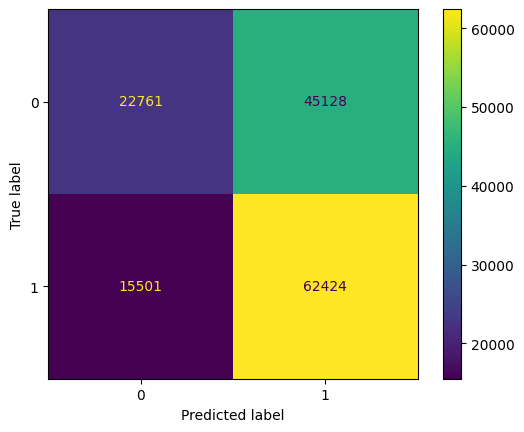

In [41]:
predictions1 = LogReg.predict(Xtest)
cm1 = confusion_matrix(Ytest, predictions1)
disp = ConfusionMatrixDisplay(confusion_matrix=cm1)
disp.plot()

In [42]:
def Predict_RF(Index=0):
    with wOutput4:
        wOutput4.clear_output()
        ds_loai = ['No Editors Choice', 'Editors Choice']
        encode =  LogReg.predict([Xtest[int(Index)]])[0]
        wOutput4.clear_output()
        print(f"Mã hóa: {encode} - Ý nghĩa: {ds_loai[encode]}")
        print(f"Mã hóa: {Ytest[int(Index)]} - Ý nghĩa: {ds_loai[Ytest[int(Index)]]}")

In [43]:
wLabel4 = widgets.Label(value='Dự đoán Editors Choice, Nhập số từ 0 đến 85813:')
display(wLabel4)
wOutput4 = widgets.Output(layout={'border': '1px solid black'})
wText4 = widgets.Text(value='0',step=1,description='0-85813')
# wOut1 = widgets.Output(layout={'border': '1px solid black'})

wKQ = widgets.interactive(Predict_RF, Index=wText4)
display(wText4)
display(wOutput4)

Label(value='Dự đoán Editors Choice, Nhập số từ 0 đến 85813:')

Text(value='0', description='0-85813')

Output(layout=Layout(border_bottom='1px solid black', border_left='1px solid black', border_right='1px solid b…

In [44]:
predictions1 = LogReg.predict(Xtest)
print(classification_report(Ytest, predictions1));

              precision    recall  f1-score   support

           0       0.59      0.34      0.43     67889
           1       0.58      0.80      0.67     77925

    accuracy                           0.58    145814
   macro avg       0.59      0.57      0.55    145814
weighted avg       0.59      0.58      0.56    145814



# 5. SMOTE

In [45]:
cols = ['Editors Choice', 'Category', 'Free', 'Rating', 'Installs', 'Content Rating', 'Price', 'Ad Supported']
new_data = new_data.filter(cols, axis=1)
new_data.head(1)

,Editors Choice,Category,Free,Rating,Installs,Content Rating,Price,Ad Supported
1,False,Tools,True,4.4,5000,Everyone,0.0,True


In [46]:
sm_data = new_data.copy()

In [47]:
sm_data = np.array(sm_data)
sm_data = sm_data.astype(str)
sm_data

array([['False', 'Tools', 'True', ..., 'Everyone', '0.0', 'True'],
       ['False', 'Personalization', 'True', ..., 'Everyone', '0.0',
        'True'],
       ['False', 'Travel & Local', 'True', ..., 'Everyone', '0.0',
        'True'],
       ...,
       ['False', 'Music & Audio', 'True', ..., 'Everyone', '0.0',
        'False'],
       ['False', 'Education', 'True', ..., 'Everyone', '0.0', 'True'],
       ['False', 'Music & Audio', 'True', ..., 'Everyone', '0.0', 'True']],
      shape=(729066, 8), dtype='<U23')

In [48]:
LE = LabelEncoder()
# print(raw_data)
# X = np.stack([LE.fit_transform(col) for col in raw_data.T[0:6]], axis=1)
features = np.stack([LE.fit_transform(sm_data.T[i]) for i in range(6)], axis=1)
target = LE.fit_transform(sm_data[:,7])
print(features.shape)
print(target.shape)

(729066, 6)
(729066,)


In [49]:

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Apply SMOTE to balance the classes
smote = SMOTE(random_state = 2)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
X_test_resampled, y_test_resampled = smote.fit_resample(X_test, y_test)

In [50]:
lr2 = LogisticRegression(solver='liblinear')
lr2.fit(X_train_resampled, y_train_resampled.ravel())
predictions2 = lr2.predict(X_test)

# print classification report
print(classification_report(y_test, predictions2))

              precision    recall  f1-score   support

           0       0.50      0.59      0.54     68105
           1       0.58      0.50      0.53     77709

    accuracy                           0.54    145814
   macro avg       0.54      0.54      0.54    145814
weighted avg       0.54      0.54      0.54    145814



In [51]:
LogReg = LogisticRegression(solver='liblinear')
LogReg.fit(X_train_resampled, y_train_resampled)
print('Training accuracy:',LogReg.score(X_train_resampled,y_train_resampled))
print('Testing accuracy:',LogReg.score(X_test_resampled,y_test_resampled))

Training accuracy: 0.5432603860182176
Testing accuracy: 0.5408897296323463


In [52]:
print(X_train_resampled.shape)
print(X_train.shape)

print(y_train_resampled.shape)
print(y_train.shape)

(624012, 6)
(583252, 6)
(624012,)
(583252,)


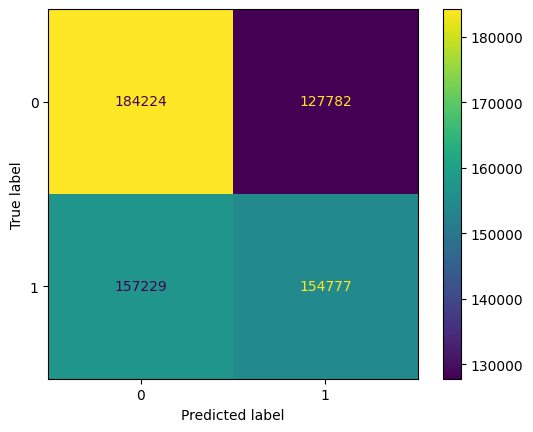

In [53]:
predictions2 = lr2.predict(X_train_resampled)
cm1 = confusion_matrix(y_train_resampled, predictions2)
disp = ConfusionMatrixDisplay(confusion_matrix=cm1)
disp.plot()

In [54]:
new_data.head(10)

,Editors Choice,Category,Free,Rating,Installs,Content Rating,Price,Ad Supported
1,False,Tools,True,4.4,5000,Everyone,0.0,True
9,False,Personalization,True,4.7,50000,Everyone,0.0,True
12,False,Travel & Local,True,3.9,10000,Everyone,0.0,True
14,False,Travel & Local,True,3.7,10000,Everyone,0.0,False
15,False,Food & Drink,True,4.2,1000,Everyone,0.0,False
16,False,Travel & Local,True,3.4,500,Everyone,0.0,False
22,False,Puzzle,True,4.4,10000,Everyone,0.0,True
23,False,Entertainment,True,3.8,500000,Everyone,0.0,True
28,False,Maps & Navigation,True,4.1,1000,Everyone,0.0,False
31,False,Travel & Local,True,3.4,10000,Everyone,0.0,False
